# 05 - Structural Stress Test

This notebook strengthens the model-risk experiment in a more structural way.

Instead of only pushing the stress correlation higher, it combines three features that should make misspecification hurt more:

- very high stress correlation,
- less frequent delta rehedging,
- more persistent stress regimes.

The true world is always the regime-switching model. The comparison is between:

- `constant` hedger: misspecified constant-correlation deltas,
- `regime` hedger: correctly specified regime-switching deltas.

The question is whether the residual hedge-error gap widens when the environment becomes structurally harsher.

In [1]:
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from IPython.display import display

plt.style.use("seaborn-v0_8-whitegrid")
np.set_printoptions(precision=4, suppress=True)

In [2]:
base_dir = Path.cwd()
repo_root = base_dir.parent if base_dir.name == "notebooks" else base_dir
data_dir = repo_root / "data" / "synthetic"

bundle = np.load(data_dir / "synthetic_market_data.npz")
asset_parameters = pd.read_csv(data_dir / "asset_parameters.csv", index_col=0)
market_settings = pd.read_csv(data_dir / "market_settings.csv", index_col=0).iloc[:, 0]

asset_names = bundle["asset_names"].tolist()
spot = bundle["spot"]
weights = bundle["weights"]
vol = bundle["vol"]
div_yield = bundle["div_yield"]
rate = float(bundle["rate"])
maturity = float(bundle["maturity"])
daily_steps = int(bundle["steps"])
start_regime = int(bundle["start_regime"])

strike = float(weights @ spot)
stress_share_target = 0.40

display(asset_parameters)
display(market_settings.to_frame(name="value"))
print(f"ATM strike used throughout: {strike:.4f}")

,spot,weight,volatility,dividend_yield
Asset 1,100.0,0.40,0.20,0.0
Asset 2,95.0,0.35,0.25,0.0
Asset 3,110.0,0.25,0.22,0.0


,value
risk_free_rate,0.03
maturity_years,1.00
time_steps,252.00
monte_carlo_paths,3000.00
rho_constant,0.35
rho_calm,0.20
rho_stress,0.75
p01,0.03
p10,0.12


ATM strike used throughout: 100.7500


## Stress-Test Settings

The stress environment is fixed at a severe correlation gap:

- constant-correlation hedge model uses `rho = 0.35`,
- calm regime uses `rho = 0.20`,
- stress regime uses `rho = 0.98`.

We then vary:

- hedge frequency: monthly to semiannual,
- persistence: via the daily switching intensity `lambda = p01 + p10`, with the long-run stress share held at 40%.

Smaller `lambda` means longer regime duration.

In [3]:
rho_constant_level = 0.35
rho_calm_level = 0.20
rho_stress_level = 0.98

hedge_steps_grid = [12, 6, 4, 2]
hedge_labels = {12: "Monthly", 6: "Bi-monthly", 4: "Quarterly", 2: "Semiannual"}
lambda_grid = [0.15, 0.08, 0.04]
repeat_count = 3

n_true_world_paths = 120
delta_mc_paths = 1200
initial_price_mc_paths = 12000
bump_fraction = 0.01

structural_config = pd.Series(
    {
        "rho_constant": rho_constant_level,
        "rho_calm": rho_calm_level,
        "rho_stress": rho_stress_level,
        "stress_share_target": stress_share_target,
        "true_world_paths": n_true_world_paths,
        "delta_mc_paths": delta_mc_paths,
        "initial_price_mc_paths": initial_price_mc_paths,
        "bump_fraction": bump_fraction,
        "repeat_count": repeat_count,
    },
    name="value",
)

display(structural_config.to_frame())

,value
rho_constant,0.35
rho_calm,0.20
rho_stress,0.98
stress_share_target,0.40
true_world_paths,120.00
delta_mc_paths,1200.00
initial_price_mc_paths,12000.00
bump_fraction,0.01
repeat_count,3.00


## Shared Helpers

In [4]:
def basket_values(prices, weights):
    return prices @ weights


def basket_call_payoff(prices, weights, strike):
    return np.maximum(basket_values(prices, weights) - strike, 0.0)


def maturity_delta(spot, weights, strike):
    basket_level = float(weights @ spot)
    if basket_level > strike:
        return weights.copy()
    if np.isclose(basket_level, strike):
        return 0.5 * weights
    return np.zeros_like(weights)


def equicorrelation_matrix(n_assets, rho):
    corr = np.full((n_assets, n_assets), rho)
    np.fill_diagonal(corr, 1.0)
    return corr


def build_transition_matrix(p01_daily, p10_daily):
    return np.array(
        [
            [1.0 - p01_daily, p01_daily],
            [p10_daily, 1.0 - p10_daily],
        ]
    )


def correlate_draws(base_draws, regime_states, chol_by_regime):
    correlated = np.empty_like(base_draws)
    for regime_value, chol in chol_by_regime.items():
        mask = regime_states == regime_value
        if np.any(mask):
            correlated[mask] = base_draws[mask] @ chol.T
    return correlated


def advance_regimes(current_regimes, transition_matrix, rng):
    prob_to_stress = transition_matrix[current_regimes, 1]
    draws = rng.random(current_regimes.size)
    return (draws < prob_to_stress).astype(np.int8)


def simulate_regime_true_world_paths(spot, rate, div_yield, vol, chol_calm, chol_stress, maturity, hedge_steps, n_paths, transition_hedge, start_regime, rng):
    n_assets = spot.size
    dt = maturity / hedge_steps
    drift = (rate - div_yield - 0.5 * vol ** 2) * dt
    diffusion = vol * np.sqrt(dt)
    chol_by_regime = {0: chol_calm, 1: chol_stress}

    paths = np.empty((n_paths, hedge_steps + 1, n_assets))
    regimes = np.empty((n_paths, hedge_steps), dtype=np.int8)
    paths[:, 0, :] = spot
    current_regimes = np.full(n_paths, start_regime, dtype=np.int8)

    for step in range(hedge_steps):
        regimes[:, step] = current_regimes
        base_draws = rng.standard_normal((n_paths, n_assets))
        correlated_draws = correlate_draws(base_draws, current_regimes, chol_by_regime)
        log_increment = drift + diffusion * correlated_draws
        paths[:, step + 1, :] = paths[:, step, :] * np.exp(log_increment)

        if step < hedge_steps - 1:
            current_regimes = advance_regimes(current_regimes, transition_hedge, rng)

    return paths, regimes


def constant_model_terminal_factors(spot, rate, div_yield, vol, tau, chol_constant, n_samples, rng):
    if tau <= 0.0:
        return np.ones((n_samples, spot.size))
    drift = (rate - div_yield - 0.5 * vol ** 2) * tau
    diffusion = vol * np.sqrt(tau)
    shocks = rng.standard_normal((n_samples, spot.size)) @ chol_constant.T
    return np.exp(drift + diffusion * shocks)


def regime_model_terminal_factors(spot, rate, div_yield, vol, hedge_dt, steps_remaining, chol_calm, chol_stress, transition_hedge, start_regime, n_samples, rng):
    if steps_remaining <= 0:
        return np.ones((n_samples, spot.size))

    drift = (rate - div_yield - 0.5 * vol ** 2) * hedge_dt
    diffusion = vol * np.sqrt(hedge_dt)
    chol_by_regime = {0: chol_calm, 1: chol_stress}
    current_regimes = np.full(n_samples, start_regime, dtype=np.int8)
    log_factors = np.zeros((n_samples, spot.size))

    for step in range(steps_remaining):
        base_draws = rng.standard_normal((n_samples, spot.size))
        correlated_draws = correlate_draws(base_draws, current_regimes, chol_by_regime)
        log_factors += drift + diffusion * correlated_draws
        if step < steps_remaining - 1:
            current_regimes = advance_regimes(current_regimes, transition_hedge, rng)

    return np.exp(log_factors)

In [5]:
def price_and_delta_from_terminal_factors(spot, terminal_factors, weights, strike, rate, tau, bump_fraction):
    terminal_prices = terminal_factors * spot
    discount = np.exp(-rate * tau)
    price = discount * basket_call_payoff(terminal_prices, weights, strike).mean()

    bump_sizes = bump_fraction * np.maximum(spot, 1.0)
    deltas = np.empty_like(spot)
    for asset_idx in range(spot.size):
        up_spot = spot[asset_idx] + bump_sizes[asset_idx]
        down_spot = max(spot[asset_idx] - bump_sizes[asset_idx], 1e-8)
        denominator = up_spot - down_spot

        up_terminal = terminal_prices.copy()
        down_terminal = terminal_prices.copy()
        up_terminal[:, asset_idx] = terminal_factors[:, asset_idx] * up_spot
        down_terminal[:, asset_idx] = terminal_factors[:, asset_idx] * down_spot

        up_payoff = basket_call_payoff(up_terminal, weights, strike)
        down_payoff = basket_call_payoff(down_terminal, weights, strike)
        deltas[asset_idx] = discount * (up_payoff.mean() - down_payoff.mean()) / denominator

    return price, deltas


def constant_model_price_and_delta(spot, tau, weights, strike, rate, div_yield, vol, chol_constant, n_samples, bump_fraction, rng):
    if tau <= 0.0:
        payoff = float(basket_call_payoff(spot[None, :], weights, strike)[0])
        return payoff, maturity_delta(spot, weights, strike)
    terminal_factors = constant_model_terminal_factors(spot, rate, div_yield, vol, tau, chol_constant, n_samples, rng)
    return price_and_delta_from_terminal_factors(spot, terminal_factors, weights, strike, rate, tau, bump_fraction)


def regime_model_price_and_delta(spot, steps_remaining, current_regime, weights, strike, rate, div_yield, vol, hedge_dt, chol_calm, chol_stress, transition_hedge, n_samples, bump_fraction, rng):
    tau = steps_remaining * hedge_dt
    if steps_remaining <= 0:
        payoff = float(basket_call_payoff(spot[None, :], weights, strike)[0])
        return payoff, maturity_delta(spot, weights, strike)
    terminal_factors = regime_model_terminal_factors(spot, rate, div_yield, vol, hedge_dt, steps_remaining, chol_calm, chol_stress, transition_hedge, current_regime, n_samples, rng)
    return price_and_delta_from_terminal_factors(spot, terminal_factors, weights, strike, rate, tau, bump_fraction)


def pnl_summary(pnl):
    return {
        "mean_pnl": float(np.mean(pnl)),
        "std_pnl": float(np.std(pnl, ddof=1)),
        "q05_pnl": float(np.quantile(pnl, 0.05)),
        "q01_pnl": float(np.quantile(pnl, 0.01)),
    }

In [6]:
def evaluate_hedger(true_paths, true_regimes, hedge_model, pricing_inputs, base_seed):
    if hedge_model == "constant":
        initial_price, initial_delta = constant_model_price_and_delta(
            spot=pricing_inputs["spot"],
            tau=pricing_inputs["maturity"],
            weights=pricing_inputs["weights"],
            strike=pricing_inputs["strike"],
            rate=pricing_inputs["rate"],
            div_yield=pricing_inputs["div_yield"],
            vol=pricing_inputs["vol"],
            chol_constant=pricing_inputs["chol_constant"],
            n_samples=pricing_inputs["initial_price_mc_paths"],
            bump_fraction=pricing_inputs["bump_fraction"],
            rng=np.random.default_rng(base_seed + 1),
        )
    else:
        initial_price, initial_delta = regime_model_price_and_delta(
            spot=pricing_inputs["spot"],
            steps_remaining=pricing_inputs["hedge_steps"],
            current_regime=pricing_inputs["start_regime"],
            weights=pricing_inputs["weights"],
            strike=pricing_inputs["strike"],
            rate=pricing_inputs["rate"],
            div_yield=pricing_inputs["div_yield"],
            vol=pricing_inputs["vol"],
            hedge_dt=pricing_inputs["hedge_dt"],
            chol_calm=pricing_inputs["chol_calm"],
            chol_stress=pricing_inputs["chol_stress"],
            transition_hedge=pricing_inputs["transition_hedge"],
            n_samples=pricing_inputs["initial_price_mc_paths"],
            bump_fraction=pricing_inputs["bump_fraction"],
            rng=np.random.default_rng(base_seed + 2),
        )

    terminal_payoff = basket_call_payoff(true_paths[:, -1, :], pricing_inputs["weights"], pricing_inputs["strike"])
    n_paths = true_paths.shape[0]
    cash_account = np.full(n_paths, initial_price) - true_paths[:, 0, :] @ initial_delta
    delta_holdings = np.tile(initial_delta, (n_paths, 1))

    for step in range(pricing_inputs["hedge_steps"] - 1):
        next_spots = true_paths[:, step + 1, :]
        cash_account *= np.exp(pricing_inputs["rate"] * pricing_inputs["hedge_dt"])
        portfolio_before = cash_account + np.sum(delta_holdings * next_spots, axis=1)
        remaining_steps = pricing_inputs["hedge_steps"] - (step + 1)
        new_deltas = np.empty_like(delta_holdings)

        for path_idx in range(n_paths):
            state_rng = np.random.default_rng(base_seed + 10000 * (step + 1) + path_idx)
            if hedge_model == "constant":
                _, state_delta = constant_model_price_and_delta(
                    spot=next_spots[path_idx],
                    tau=remaining_steps * pricing_inputs["hedge_dt"],
                    weights=pricing_inputs["weights"],
                    strike=pricing_inputs["strike"],
                    rate=pricing_inputs["rate"],
                    div_yield=pricing_inputs["div_yield"],
                    vol=pricing_inputs["vol"],
                    chol_constant=pricing_inputs["chol_constant"],
                    n_samples=pricing_inputs["delta_mc_paths"],
                    bump_fraction=pricing_inputs["bump_fraction"],
                    rng=state_rng,
                )
            else:
                _, state_delta = regime_model_price_and_delta(
                    spot=next_spots[path_idx],
                    steps_remaining=remaining_steps,
                    current_regime=int(true_regimes[path_idx, step + 1]),
                    weights=pricing_inputs["weights"],
                    strike=pricing_inputs["strike"],
                    rate=pricing_inputs["rate"],
                    div_yield=pricing_inputs["div_yield"],
                    vol=pricing_inputs["vol"],
                    hedge_dt=pricing_inputs["hedge_dt"],
                    chol_calm=pricing_inputs["chol_calm"],
                    chol_stress=pricing_inputs["chol_stress"],
                    transition_hedge=pricing_inputs["transition_hedge"],
                    n_samples=pricing_inputs["delta_mc_paths"],
                    bump_fraction=pricing_inputs["bump_fraction"],
                    rng=state_rng,
                )
            new_deltas[path_idx] = state_delta

        cash_account = portfolio_before - np.sum(new_deltas * next_spots, axis=1)
        delta_holdings = new_deltas

    cash_account *= np.exp(pricing_inputs["rate"] * pricing_inputs["hedge_dt"])
    pnl = cash_account + np.sum(delta_holdings * true_paths[:, -1, :], axis=1) - terminal_payoff
    return {"initial_price": initial_price, **pnl_summary(pnl)}


def run_structural_scenario(hedge_steps, lambda_daily, repeat_id, scenario_seed):
    days_per_hedge_step = daily_steps // hedge_steps
    hedge_dt = maturity / hedge_steps
    p01_daily = stress_share_target * lambda_daily
    p10_daily = (1.0 - stress_share_target) * lambda_daily

    chol_constant = np.linalg.cholesky(equicorrelation_matrix(spot.size, rho_constant_level))
    chol_calm = np.linalg.cholesky(equicorrelation_matrix(spot.size, rho_calm_level))
    chol_stress = np.linalg.cholesky(equicorrelation_matrix(spot.size, rho_stress_level))

    transition_daily = build_transition_matrix(p01_daily, p10_daily)
    transition_hedge = np.linalg.matrix_power(transition_daily, days_per_hedge_step)

    pricing_inputs = {
        "spot": spot,
        "weights": weights,
        "strike": strike,
        "rate": rate,
        "div_yield": div_yield,
        "vol": vol,
        "maturity": maturity,
        "hedge_steps": hedge_steps,
        "hedge_dt": hedge_dt,
        "delta_mc_paths": delta_mc_paths,
        "initial_price_mc_paths": initial_price_mc_paths,
        "bump_fraction": bump_fraction,
        "chol_constant": chol_constant,
        "chol_calm": chol_calm,
        "chol_stress": chol_stress,
        "transition_hedge": transition_hedge,
        "start_regime": start_regime,
    }

    true_paths, true_regimes = simulate_regime_true_world_paths(
        spot=spot,
        rate=rate,
        div_yield=div_yield,
        vol=vol,
        chol_calm=chol_calm,
        chol_stress=chol_stress,
        maturity=maturity,
        hedge_steps=hedge_steps,
        n_paths=n_true_world_paths,
        transition_hedge=transition_hedge,
        start_regime=start_regime,
        rng=np.random.default_rng(scenario_seed),
    )

    rows = []
    for hedger_idx, hedger in enumerate(["constant", "regime"]):
        summary = evaluate_hedger(
            true_paths=true_paths,
            true_regimes=true_regimes,
            hedge_model=hedger,
            pricing_inputs=pricing_inputs,
            base_seed=scenario_seed + 1000 * (hedger_idx + 1),
        )
        rows.append(
            {
                "hedge_steps": hedge_steps,
                "hedge_label": hedge_labels[hedge_steps],
                "days_per_hedge_step": days_per_hedge_step,
                "lambda_daily": lambda_daily,
                "p01_daily": p01_daily,
                "p10_daily": p10_daily,
                "expected_stress_duration_days": 1.0 / p10_daily,
                "repeat_id": repeat_id,
                "avg_stress_fraction": float(true_regimes.mean()),
                "hedger": hedger,
                **summary,
            }
        )

    return pd.DataFrame(rows)

## Structural Stress Grid

In [7]:
raw_rows = []
for hedge_steps_idx, hedge_steps in enumerate(hedge_steps_grid, start=1):
    for lambda_idx, lambda_daily in enumerate(lambda_grid, start=1):
        for repeat_id in range(repeat_count):
            scenario_seed = 21000 + 3000 * hedge_steps_idx + 300 * lambda_idx + 25 * repeat_id
            raw_rows.append(run_structural_scenario(hedge_steps, lambda_daily, repeat_id, scenario_seed))

structural_raw = pd.concat(raw_rows, ignore_index=True)

structural_summary = (
    structural_raw.groupby(["hedge_steps", "hedge_label", "days_per_hedge_step", "lambda_daily", "expected_stress_duration_days", "hedger"], as_index=False)
    .agg(
        avg_initial_price=("initial_price", "mean"),
        avg_std_pnl=("std_pnl", "mean"),
        std_of_std_pnl=("std_pnl", "std"),
        avg_q05_pnl=("q05_pnl", "mean"),
        avg_q01_pnl=("q01_pnl", "mean"),
        std_of_q01_pnl=("q01_pnl", "std"),
        avg_mean_pnl=("mean_pnl", "mean"),
        avg_stress_fraction=("avg_stress_fraction", "mean"),
    )
)

structural_gap = structural_summary.pivot(
    index=["hedge_steps", "hedge_label", "days_per_hedge_step", "lambda_daily", "expected_stress_duration_days"],
    columns="hedger",
    values=["avg_std_pnl", "avg_q01_pnl", "avg_mean_pnl"],
)
structural_gap.columns = ["_".join(col).strip() for col in structural_gap.columns.to_flat_index()]
structural_gap = structural_gap.reset_index()
structural_gap["std_gap_constant_minus_regime"] = structural_gap["avg_std_pnl_constant"] - structural_gap["avg_std_pnl_regime"]
structural_gap["q01_gap_regime_minus_constant"] = structural_gap["avg_q01_pnl_regime"] - structural_gap["avg_q01_pnl_constant"]
structural_gap["mean_gap_regime_minus_constant"] = structural_gap["avg_mean_pnl_regime"] - structural_gap["avg_mean_pnl_constant"]

display(structural_summary.round(4))
display(structural_gap.round(4))

,hedge_steps,hedge_label,days_per_hedge_step,lambda_daily,expected_stress_duration_days,hedger,avg_initial_price,avg_std_pnl,std_of_std_pnl,avg_q05_pnl,avg_q01_pnl,std_of_q01_pnl,avg_mean_pnl,avg_stress_fraction
0,2,Semiannual,126,0.04,41.6667,constant,8.2054,4.1241,0.5093,-6.7426,-13.8183,2.9460,-0.1112,0.1931
1,2,Semiannual,126,0.04,41.6667,regime,8.1615,4.1149,0.4594,-7.2024,-12.9515,2.0888,-0.1884,0.1931
2,2,Semiannual,126,0.08,20.8333,constant,8.2818,4.3827,0.2803,-6.9400,-14.6342,3.9213,-0.1256,0.2069
3,2,Semiannual,126,0.08,20.8333,regime,8.2190,4.2811,0.1830,-6.7271,-14.2377,3.6242,-0.1608,0.2069
4,2,Semiannual,126,0.15,11.1111,constant,8.3117,3.7835,0.3343,-7.0115,-11.0858,1.9979,-0.1398,0.1986
5,2,Semiannual,126,0.15,11.1111,regime,8.2738,3.7892,0.2903,-6.9456,-10.2739,1.7675,-0.1891,0.1986
6,4,Quarterly,63,0.04,41.6667,constant,8.1964,3.0807,0.3511,-5.5093,-8.9551,0.9020,-0.4279,0.3076
7,4,Quarterly,63,0.04,41.6667,regime,8.5319,3.0677,0.2412,-5.1153,-8.3054,0.4437,-0.0974,0.3076
8,4,Quarterly,63,0.08,20.8333,constant,8.2645,3.3730,0.4274,-6.7478,-9.4066,2.9177,-0.6618,0.3299
9,4,Quarterly,63,0.08,20.8333,regime,8.5529,3.3426,0.4308,-5.9071,-8.6324,2.3432,-0.3461,0.3299


,hedge_steps,hedge_label,days_per_hedge_step,lambda_daily,expected_stress_duration_days,avg_std_pnl_constant,avg_std_pnl_regime,avg_q01_pnl_constant,avg_q01_pnl_regime,avg_mean_pnl_constant,avg_mean_pnl_regime,std_gap_constant_minus_regime,q01_gap_regime_minus_constant,mean_gap_regime_minus_constant
0,2,Semiannual,126,0.04,41.6667,4.1241,4.1149,-13.8183,-12.9515,-0.1112,-0.1884,0.0092,0.8668,-0.0772
1,2,Semiannual,126,0.08,20.8333,4.3827,4.2811,-14.6342,-14.2377,-0.1256,-0.1608,0.1016,0.3965,-0.0352
2,2,Semiannual,126,0.15,11.1111,3.7835,3.7892,-11.0858,-10.2739,-0.1398,-0.1891,-0.0057,0.8119,-0.0493
3,4,Quarterly,63,0.04,41.6667,3.0807,3.0677,-8.9551,-8.3054,-0.4279,-0.0974,0.0130,0.6496,0.3305
4,4,Quarterly,63,0.08,20.8333,3.3730,3.3426,-9.4066,-8.6324,-0.6618,-0.3461,0.0303,0.7742,0.3156
5,4,Quarterly,63,0.15,11.1111,2.9815,2.9525,-8.3068,-7.9144,-0.1274,0.1768,0.0290,0.3923,0.3042
6,6,Bi-monthly,42,0.04,41.6667,2.4522,2.4945,-6.9847,-6.2523,-0.0744,0.2840,-0.0423,0.7325,0.3585
7,6,Bi-monthly,42,0.08,20.8333,2.7277,2.6912,-8.2061,-6.7366,-0.4198,0.1367,0.0365,1.4695,0.5565
8,6,Bi-monthly,42,0.15,11.1111,2.4688,2.4495,-7.3397,-6.2939,-0.0837,0.3498,0.0192,1.0459,0.4334
9,12,Monthly,21,0.04,41.6667,2.0721,1.9610,-6.7834,-5.3854,-0.5354,-0.0758,0.1112,1.3980,0.4596


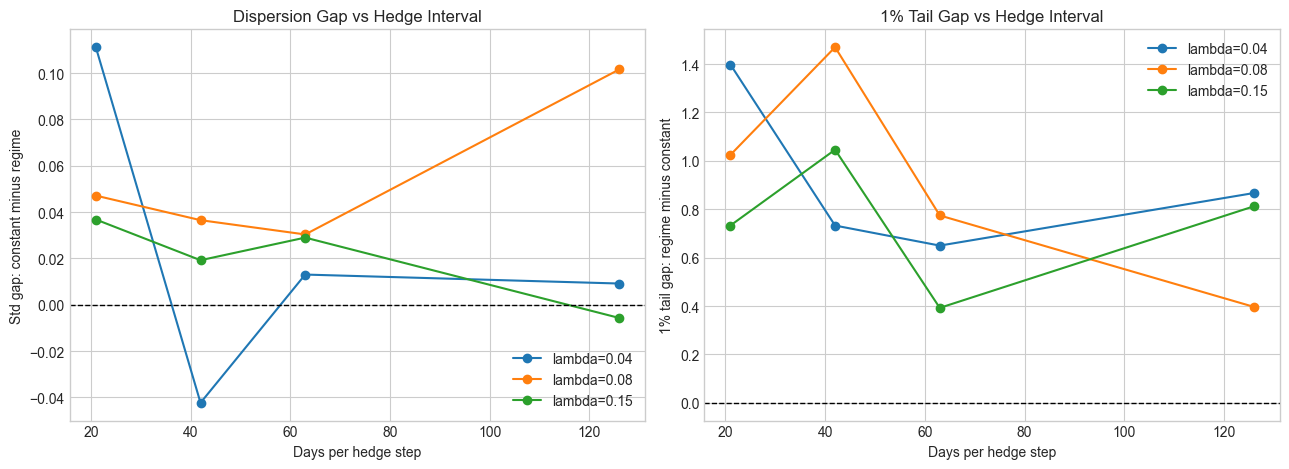

In [8]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4.8))

for lambda_daily, frame in structural_gap.groupby("lambda_daily"):
    frame = frame.sort_values("days_per_hedge_step")
    label = f"lambda={lambda_daily:.2f}"
    axes[0].plot(frame["days_per_hedge_step"], frame["std_gap_constant_minus_regime"], marker="o", label=label)
    axes[1].plot(frame["days_per_hedge_step"], frame["q01_gap_regime_minus_constant"], marker="o", label=label)

axes[0].axhline(0.0, color="black", linestyle="--", linewidth=1.0)
axes[0].set_title("Dispersion Gap vs Hedge Interval")
axes[0].set_xlabel("Days per hedge step")
axes[0].set_ylabel("Std gap: constant minus regime")
axes[0].legend()

axes[1].axhline(0.0, color="black", linestyle="--", linewidth=1.0)
axes[1].set_title("1% Tail Gap vs Hedge Interval")
axes[1].set_xlabel("Days per hedge step")
axes[1].set_ylabel("1% tail gap: regime minus constant")
axes[1].legend()

plt.tight_layout()
plt.show()

Positive values in the gap plots mean the correctly specified regime-switching hedge is doing better:

- positive `std gap` means lower P&L dispersion under the regime hedge,
- positive `1% tail gap` means a less negative left tail under the regime hedge.

If the lines move upward as the hedge interval widens or stress becomes more persistent, that is evidence that misspecification hurts more in structurally harsher settings.

## Persist Outputs

In [9]:
structural_raw.to_csv(data_dir / "basket_option_structural_stress_raw.csv", index=False)
structural_summary.to_csv(data_dir / "basket_option_structural_stress_summary.csv", index=False)
structural_gap.to_csv(data_dir / "basket_option_structural_stress_gap.csv", index=False)
structural_config.to_csv(data_dir / "basket_option_structural_stress_config.csv")

print(f"Saved raw structural stress runs to {data_dir / 'basket_option_structural_stress_raw.csv'}")
print(f"Saved structural stress summary to {data_dir / 'basket_option_structural_stress_summary.csv'}")
print(f"Saved structural stress gap table to {data_dir / 'basket_option_structural_stress_gap.csv'}")
print(f"Saved structural stress config to {data_dir / 'basket_option_structural_stress_config.csv'}")

Saved raw structural stress runs to /Users/hamzaahmed/Multi-Asset Option Pricing/data/synthetic/basket_option_structural_stress_raw.csv
Saved structural stress summary to /Users/hamzaahmed/Multi-Asset Option Pricing/data/synthetic/basket_option_structural_stress_summary.csv
Saved structural stress gap table to /Users/hamzaahmed/Multi-Asset Option Pricing/data/synthetic/basket_option_structural_stress_gap.csv
Saved structural stress config to /Users/hamzaahmed/Multi-Asset Option Pricing/data/synthetic/basket_option_structural_stress_config.csv
